# Retail Revenue & Retention Analytics

**Tools:** Python (pandas) · SQL · Power BI
**Data:** [UCI Machine Learning Repository - Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) - 1,067,371 real transactions from a UK online retailer, Dec 2009 - Dec 2011

---

I wanted a project where I had to deal with data that was actually messy, rather than a
tidy Kaggle CSV where the hard part is already done. This dataset is one flat Excel sheet
with duplicates, missing customer IDs, cancellation invoices mixed in with real sales,
and no category or cost columns at all.

So the project is the whole journey: profile the mess, clean it, model it into a proper
7-table star schema, then actually answer the two questions a retail business cares about.

### The two questions

1. **Where does revenue leak away?** (returns, cancellations, thin-margin categories)
2. **Which customers are actually worth keeping?** (concentration, cohorts, churn)

### What I found

| | |
|---|---|
| **€2,428,192** | revenue across **62,316 transactions** |
| **65.7%** | of revenue comes from just the **top 10%** of customers |
| **29.7%** | of customers bought once and never came back - worth only **4.7%** of revenue |
| **20.9%** | month-1 retention, then it *flattens* rather than continuing to fall |
| **€58,192** | lost to returns (2.3% of gross demand) |

> **One thing stated up front:** this dataset has a selling price but **no cost column**,
> so profit margin cannot be measured from it. I apply a documented per-category cost
> model and calibrate it to a 20% blended margin. Every revenue and customer number below
> is measured from the real data; **the margin is modelled**, and I flag it every time it
> appears. I would rather say that here than have someone find it later.

## Setup

The colours are a fixed palette I use for every chart so the whole notebook reads as one
thing. Blue is the default single-series colour; orange only appears when there are two
series to tell apart.

In [1]:
import os, sys, sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
sys.path.append(os.path.join("..", "python"))
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# --- my palette ----------------------------------------------------------------------
# I fixed these once at the top instead of picking colours per chart. My first draft used
# a different default colour in every cell and the notebook looked like five different
# people wrote it. Blue is my default for a single series; orange only shows up when
# there are two things to tell apart; red is reserved for "this is money we lost" so it
# never means just another category.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED               = "#d03b3b"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE     = "#e1e0d9", "#fcfcfb"
BLUES = LinearSegmentedColormap.from_list("blues", ["#eaf2fd", "#9ec5f4", "#3987e5", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 120,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "axes.axisbelow": True,        # gridlines behind the bars, not drawn across them
    "legend.frameon": False,
})

# Axis labels. I used ":.1f" here at first and my tick labels came out 1.0M, 1.2M, 1.5M,
# 1.8M - which made evenly spaced ticks look uneven, because 1.25M was being rounded to
# 1.2M. Switching to ":g" gives €1.25M and the spacing reads correctly.
eur  = FuncFormatter(lambda v, _: f"€{v/1000:,.0f}k" if v < 1e6 else f"€{v/1e6:g}M")
pct  = FuncFormatter(lambda v, _: f"{v*100:.0f}%")

def on_dark(rgba):
    '''Decide whether text on this colour should be white.

    I wrote this after my cohort heat map came out unreadable. I had guessed a cutoff
    (if the value is above 18, use white text) but the value is not the same thing as
    how dark the cell actually is. This works out the real brightness of the colour and
    lets that decide, so it stays readable whatever I set the scale to.'''
    r, g, b = rgba[:3]
    return (0.2126*r + 0.7152*g + 0.0722*b) < 0.55

def label_bars(ax, bars, fmt="{:,.0f}", pad=3, color=INK_2):
    '''Write the value at the end of each bar.

    I kept squinting at my own bar charts trying to read a value off the axis, so I
    started putting the number on the bar instead. It also means a one-series chart
    needs no legend at all.'''
    for b in bars:
        w = b.get_width()
        ax.text(w + pad, b.get_y() + b.get_height()/2, fmt.format(w),
                va="center", ha="left", fontsize=8.5, color=color)

print("ready")

ready


## Step 1 - What the raw file actually looks like

The download is a single `.xlsx` with two sheets, one per year. First thing I do with any
new dataset is stop and count what is wrong with it, before touching anything.

In [2]:
RAW = os.path.join("..", "data_raw", "online_retail_II.xlsx")

sheets = pd.read_excel(RAW, sheet_name=None, engine="openpyxl")
raw = pd.concat(sheets.values(), ignore_index=True).rename(columns={"Customer ID": "CustomerID"})

print(f"{len(raw):,} rows across {len(sheets)} sheets")
print(f"{raw['InvoiceDate'].min()}  ->  {raw['InvoiceDate'].max()}")
raw.head()

1,067,371 rows across 2 sheets
2009-12-01 07:45:00  ->  2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Before I delete anything I want to know exactly what I am dealing with. I make myself
# write this table first, because later on every single row I drop has to trace back to a
# line in here - otherwise I am just deleting data until the numbers look nice.
inv = raw["Invoice"].astype(str)
problems = {
    "Exact duplicate rows":              raw.duplicated().sum(),
    "No Customer ID":                    raw["CustomerID"].isna().sum(),
    "No Description":                    raw["Description"].isna().sum(),
    "Cancellation invoices (start 'C')": inv.str.upper().str.startswith("C").sum(),
    "Quantity <= 0":                     (raw["Quantity"] <= 0).sum(),
    "Price <= 0":                        (raw["Price"] <= 0).sum(),
    "Price > 2,000 (adjustments)":       (raw["Price"] > 2000).sum(),
    "|Quantity| > 2,000":                (raw["Quantity"].abs() > 2000).sum(),
}
report = pd.DataFrame({"rows": pd.Series(problems)})
report["% of file"] = (report["rows"] / len(raw) * 100).round(2)
report

,rows,% of file
Exact duplicate rows,34335,3.22
No Customer ID,243007,22.77
No Description,4382,0.41
Cancellation invoices (start 'C'),19494,1.83
Quantity <= 0,22950,2.15
Price <= 0,6207,0.58
"Price > 2,000 (adjustments)",140,0.01
"|Quantity| > 2,000",228,0.02


Nearly **a quarter of the file has no Customer ID**. That single fact shapes the whole
project - without a customer ID you cannot do cohort analysis, retention, or any kind of
customer segmentation, which is exactly what I set out to do. Those rows have to go, and
I have to be honest that I am therefore analysing the *identified* customer base, not
every sale the company made.

The other big one is the cancellation invoices. Invoice numbers starting with `C` are
cancelled or returned orders and they carry **negative quantities**. Plenty of tutorials
just filter out negative quantities and move on - but that throws away the returns data,
and returns *are* the revenue leakage story. So I keep them, flagged separately.

## Step 2 - Cleaning

Each step below removes one specific problem from the table above, and I log how many
rows each one costs me. If I cannot explain why a row disappeared, I have done something
wrong.

In [4]:
log = []
def step(label, df):
    log.append((label, step.prev - len(df), len(df)))
    step.prev = len(df)
    return df

df = raw.copy()
step.prev = len(df)
log.append(("Raw rows loaded", 0, len(df)))

# Tidy up the text before anything else. I skipped this the first time and my stock-code
# filter missed a load of rows, because some codes had a trailing space and some were
# lowercase, so "post" never matched "POST".
df["Invoice"]     = df["Invoice"].astype(str).str.strip().str.upper()
df["StockCode"]   = df["StockCode"].astype(str).str.strip().str.upper()
df["Description"] = df["Description"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
df["Country"]     = df["Country"].astype(str).str.strip()

df = step("Dropped exact duplicate rows", df.drop_duplicates())

# I have to pull the cancellations out HERE, before the quantity filter further down.
# Cancellations carry negative quantities, so if I filter on Quantity > 0 first they all
# disappear and I never notice - which is exactly what happened in my first attempt, and
# it is why my returns number came out as zero.
is_cancel = df["Invoice"].str.startswith("C")
cancels   = df[is_cancel].copy()
df        = step("Split out cancellation invoices", df[~is_cancel].copy())

df = step("Dropped rows with no Customer ID", df.dropna(subset=["CustomerID"]))

# These are real rows but they are not products - POST is postage, M is a manual
# adjustment, BANK CHARGES is a fee. I found them by sorting the stock codes and noticing
# the ones that were not 5-digit numbers.
NON_PRODUCT = {"POST","DOT","C2","M","S","B","D","CRUK","PADS","GIFT","TEST001","TEST002",
               "AMAZONFEE","BANK CHARGES","ADJUST","ADJUST2","SP1002"}
df = step("Dropped non-product stock codes", df[~df["StockCode"].isin(NON_PRODUCT)])
df = step("Dropped non-numeric stock codes", df[df["StockCode"].str.match(r"^\d{5}")])

df = step("Dropped Price <= 0",        df[df["Price"] > 0])
df = step("Dropped Quantity <= 0",     df[df["Quantity"] > 0])
df = step("Dropped Price > 2,000",     df[df["Price"] <= 2000])
df = step("Dropped Quantity > 2,000",  df[df["Quantity"] <= 2000])

pd.DataFrame(log, columns=["step", "rows removed", "rows remaining"])

,step,rows removed,rows remaining
0,Raw rows loaded,0,1067371
1,Dropped exact duplicate rows,34335,1033036
2,Split out cancellation invoices,19104,1013932
3,Dropped rows with no Customer ID,234437,779495
4,Dropped non-product stock codes,2858,776637
5,Dropped non-numeric stock codes,0,776637
6,Dropped Price <= 0,60,776577
7,Dropped Quantity <= 0,0,776577
8,"Dropped Price > 2,000",0,776577
9,"Dropped Quantity > 2,000",116,776461


## Step 3 - Choosing the scope (and why)

Three decisions here. Each one changes the headline numbers, so each one needs a reason
better than "it made the chart look nicer".

In [5]:
by_country = (df.assign(rev=df["Price"] * df["Quantity"])
                .groupby("Country")
                .agg(rows=("rev", "size"), revenue_gbp=("rev", "sum"), customers=("CustomerID", "nunique"))
                .sort_values("revenue_gbp", ascending=False))
by_country.head(8).style.format({"rows": "{:,.0f}", "revenue_gbp": "£{:,.0f}"})

,rows,revenue_gbp,customers
Country,,,
United Kingdom,"699,544","£13,929,252",5334
EIRE,"15,349","£586,626",3
Netherlands,"4,980","£544,781",22
Germany,"15,787","£383,289",107
France,"13,017","£301,627",93
Australia,"1,783","£167,800",15
Spain,"3,560","£97,767",38
Switzerland,"2,951","£93,401",22


**Decision 1 - drop the UK.** It is 91% of the rows and about 84% of revenue. The export
business is a segment the company would report on separately anyway, and it is the one
where "do these customers come back?" is a live question.

**Decision 2 - drop EIRE.** Look at the table above: EIRE is the biggest export market by
revenue but has almost no customers. Let me check that properly, because it looks wrong.

In [6]:
eire = df[df["Country"] == "EIRE"].assign(rev=lambda d: d["Price"] * d["Quantity"])
per_account = eire.groupby("CustomerID")["rev"].sum().sort_values(ascending=False)
print(f"EIRE customers: {eire['CustomerID'].nunique()}")
print(f"EIRE revenue  : £{eire['rev'].sum():,.0f}\n")
print(per_account.apply(lambda v: f"£{v:,.0f}").to_string())

EIRE customers: 3
EIRE revenue  : £586,626

CustomerID
14156.0    £303,070
14911.0    £272,253
14016.0     £11,303


**Three accounts.** The two largest are worth £303k and £272k on their own - together
that is 98% of the entire Irish market. That is a wholesale or
distribution relationship, not export retail behaviour - and with only ~500 customers in
the whole export segment, leaving these three in would dominate every single
customer-level metric I am about to calculate. Out they go, and I say so rather than
quietly dropping them.

**Decision 3 - complete months only.** The file stops mid-month on 2011-12-09. If I leave
December in, the last point of every monthly trend line falls off a cliff for no real
reason and it looks like the business collapsed.

In [7]:
EXCLUDE = ["United Kingdom", "EIRE"]
END     = "2011-12-01"

df = step("Excluded home market (UK)",        df[~df["Country"].isin(["United Kingdom"])])
df = step("Excluded wholesale market (EIRE)", df[df["Country"] != "EIRE"])
df = step("Trimmed partial final month",      df[pd.to_datetime(df["InvoiceDate"]) < END])

# Now I put the returns through exactly the same filters as the sales, flip the negative
# quantities to positive, and label them so I can always tell the two apart. I want them
# in the table - returns are the revenue-leakage story - but they must never sneak into
# a revenue total.
cancels["Quantity"] = cancels["Quantity"].abs()
cancels = cancels.dropna(subset=["CustomerID"])
cancels = cancels[(cancels["Price"] > 0) & (cancels["Price"] <= 2000) & (cancels["Quantity"] <= 2000)
                  & (~cancels["StockCode"].isin(NON_PRODUCT))
                  & (cancels["StockCode"].str.match(r"^\d{5}"))
                  & (~cancels["Country"].isin(EXCLUDE))
                  & (pd.to_datetime(cancels["InvoiceDate"]) < END)]

df["order_status"], cancels["order_status"] = "Completed", "Returned"
clean = pd.concat([df, cancels], ignore_index=True)
step("Added cleaned return lines back in", clean)

# I only spotted this because I ran a duplicate check on (invoice, product) expecting
# zero rows and got 128 back. Some invoices genuinely list the same product twice, at
# slightly different prices. That is fine in the source system, but I want one row per
# product per order, so I add the quantities together and take a price weighted by value.
# Doing it that way keeps the invoice total identical - only the row count changes.
clean["_v"] = clean["Price"] * clean["Quantity"]
clean = clean.groupby(["Invoice", "StockCode", "order_status"], as_index=False).agg(
    Description=("Description","first"), Quantity=("Quantity","sum"), _v=("_v","sum"),
    InvoiceDate=("InvoiceDate","min"), CustomerID=("CustomerID","first"), Country=("Country","first"))
clean["Price"] = (clean["_v"] / clean["Quantity"]).round(4)
clean = clean.drop(columns="_v")
step("Consolidated repeated lines in an invoice", clean)

pd.DataFrame(log, columns=["step", "rows removed", "rows remaining"]).tail(6)

,step,rows removed,rows remaining
9,"Dropped Quantity > 2,000",116,776461
10,Excluded home market (UK),699544,76917
11,Excluded wholesale market (EIRE),15349,61568
12,Trimmed partial final month,1135,60433
13,Added cleaned return lines back in,-2017,62450
14,Consolidated repeated lines in an invoice,134,62316


From **1,067,371 raw rows to 62,316 clean transactions**. That is a brutal reduction, but
almost all of it is the UK filter - a scope choice, not data loss.

## Step 4 - Building the star schema

The raw file is one flat table with no category, no cost, no brand. To do anything useful
I need a proper dimensional model - 5 dimensions and 2 facts.

Two columns have to be **engineered** because they simply are not in the source:

- **Category** - derived from the free-text `Description` with a keyword classifier
  (`WHITE HANGING HEART T-LIGHT HOLDER` → *Home Decor & Lighting*). I keep the rules in
  `python/clean_online_retail.py` so the notebook and the pipeline cannot drift apart.
- **Cost** - does not exist at all. Each category gets a relative gross margin (giftware
  high, bulk low), and the whole set is scaled by one factor so the blended margin lands
  on 20%. **The relative differences are my judgement; the level is an assumption.**

In [8]:
from clean_online_retail import derive_category, CATEGORY_MARGINS, CATEGORY_DEPARTMENTS

GBP_TO_EUR, TARGET_MARGIN = 1.15, 0.20

clean["order_date"]    = pd.to_datetime(clean["InvoiceDate"]).dt.normalize()
clean["unit_price"]    = (clean["Price"] * GBP_TO_EUR).round(2)
clean["category_name"] = clean["Description"].map(derive_category)

# Here is the honest bit. There is no cost column, so I cannot measure margin - I have to
# assume it. What I do is give each category a sensible margin relative to the others
# (giftware earns more than bulk items), then scale the whole set by one number until the
# overall margin lands on 20%. So the shape of the model is my judgement and the level is
# an assumption. I print the scale factor so it is visible rather than buried.
done   = clean[clean["order_status"] == "Completed"]
rev    = (done["unit_price"] * done["Quantity"]).groupby(done["category_name"]).sum()
blend  = sum(rev.get(c, 0) * CATEGORY_MARGINS[c] for c in rev.index) / rev.sum()
scale  = TARGET_MARGIN / blend
margin = {c: CATEGORY_MARGINS[c] * scale for c in clean["category_name"].unique()}
print(f"Relative margins scaled by {scale:.4f} -> blended margin = {TARGET_MARGIN:.0%}")

clean["unit_cost"]    = (clean["unit_price"] * clean["category_name"].map(margin).rsub(1)).round(2)
clean["line_revenue"] = (clean["unit_price"] * clean["Quantity"]).round(2)
clean["line_cost"]    = (clean["unit_cost"]  * clean["Quantity"]).round(2)
clean["line_profit"]  = (clean["line_revenue"] - clean["line_cost"]).round(2)

Relative margins scaled by 0.7501 -> blended margin = 20%


In [9]:
# ---- building the 7 tables ----------------------------------------------------------
# The pattern is the same every time: pull out the distinct values, give them an ID, then
# map that ID back onto the fact table. It felt long-winded the first time I did it, but
# it is what stops me repeating a product name 62,000 times.
cats = sorted(clean["category_name"].unique())
cat_id = {c: i+1 for i, c in enumerate(cats)}
dim_categories = pd.DataFrame({"category_id": [cat_id[c] for c in cats], "category_name": cats,
                               "department": [CATEGORY_DEPARTMENTS.get(c, "Home") for c in cats],
                               "target_margin_pct": [round(margin[c]*100, 2) for c in cats]})

prod = (clean.groupby("StockCode")
             .agg(product_name=("Description", lambda s: s.mode().iat[0]),
                  unit_price=("unit_price", "median"), unit_cost=("unit_cost", "median"))
             .reset_index())
prod["category_id"] = prod["product_name"].map(derive_category).map(cat_id)
prod["product_id"]  = range(1, len(prod)+1)
dim_products = prod[["product_id","product_name","category_id","unit_price","unit_cost"]]
sku_to_pid = dict(zip(prod["StockCode"], prod["product_id"]))

# I called this dim_stores even though this retailer is online-only and has no shops.
# The nearest real equivalent in the data is the destination country, so that is what a
# "store" is here. I kept the name so the same SQL and the same Power BI model work
# against this dataset and the synthetic one without changing a single query.
countries = sorted(clean["Country"].unique())
dim_stores = pd.DataFrame({"store_id": range(1, len(countries)+1), "store_name": countries,
                           "channel": "Online", "country": countries, "region": "International Export"})
ctry_to_sid = dict(zip(dim_stores["country"], dim_stores["store_id"]))

cust = (clean.groupby("CustomerID")
             .agg(signup_date=("order_date","min"), country=("Country", lambda s: s.mode().iat[0]))
             .reset_index().rename(columns={"CustomerID":"customer_id"}))
cust["customer_id"] = cust["customer_id"].astype(int)
dim_customers = cust

d = pd.date_range(clean["order_date"].min(), clean["order_date"].max(), freq="D")
dim_date = pd.DataFrame({"full_date": d, "year": d.year, "month_number": d.month,
                         "year_month": d.strftime("%Y-%m"), "quarter": "Q" + d.quarter.astype(str),
                         "day_name": d.strftime("%A")})

clean["product_id"] = clean["StockCode"].map(sku_to_pid)
clean["store_id"]   = clean["Country"].map(ctry_to_sid)
orders = (clean.groupby("Invoice")
               .agg(customer_id=("CustomerID","first"), store_id=("store_id","first"),
                    order_date=("order_date","min"), order_status=("order_status","first"),
                    n_items=("StockCode","size")).reset_index().sort_values("order_date"))
orders["order_id"] = range(1, len(orders)+1)
orders["customer_id"] = orders["customer_id"].astype(int)
inv_to_oid = dict(zip(orders["Invoice"], orders["order_id"]))
fact_orders = orders[["order_id","customer_id","store_id","order_date","order_status","n_items"]]

items = clean.copy()
items["order_id"] = items["Invoice"].map(inv_to_oid)
items = items.sort_values("order_id").reset_index(drop=True)
items["order_item_id"] = range(1, len(items)+1)
fact_order_items = items[["order_item_id","order_id","product_id","Quantity","unit_price",
                          "unit_cost","line_revenue","line_cost","line_profit"]].rename(
                          columns={"Quantity":"quantity"})

TABLES = {"dim_date": dim_date, "dim_customers": dim_customers, "dim_categories": dim_categories,
          "dim_products": dim_products, "dim_stores": dim_stores,
          "fact_orders": fact_orders, "fact_order_items": fact_order_items}

pd.DataFrame([(n, f"{len(t):,}", ", ".join(t.columns[:5]) + ("..." if len(t.columns) > 5 else ""))
              for n, t in TABLES.items()], columns=["table", "rows", "columns (first 5)"])

,table,rows,columns (first 5)
0,dim_date,730,"full_date, year, month_number, year_month, qua..."
1,dim_customers,508,"customer_id, signup_date, country"
2,dim_categories,11,"category_id, category_name, department, target..."
3,dim_products,"3,383","product_id, product_name, category_id, unit_pr..."
4,dim_stores,39,"store_id, store_name, channel, country, region"
5,fact_orders,"3,280","order_id, customer_id, store_id, order_date, o..."
6,fact_order_items,"62,316","order_item_id, order_id, product_id, quantity,..."


## Step 5 - Into SQL

The dashboard and the analysis both run on SQL, so from here on I query the tables rather
than using pandas. I load them into SQLite in-memory - it needs no install and supports
the window functions and CTEs the analysis depends on. (The same queries run on
PostgreSQL; the files are in `sql/`.)

In [10]:
con = sqlite3.connect(":memory:")
for name, table in TABLES.items():
    out = table.copy()
    # SQLite has no real date type, so I write dates as YYYY-MM-DD text. They still sort
    # and compare correctly that way, which is all my queries need.
    for c in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[c]):
            out[c] = out[c].dt.strftime("%Y-%m-%d")
    out.to_sql(name, con, index=False)

def q(sql):
    "Shorthand so I can just write q('SELECT ...') and get a DataFrame back."
    return pd.read_sql(sql, con)

q("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")

,name
0,dim_categories
1,dim_customers
2,dim_date
3,dim_products
4,dim_stores
5,fact_order_items
6,fact_orders


---

# Finding 1 - The headline numbers

One rule runs through every query from here on: **revenue only counts when
`order_status = 'Completed'`**. Returns are tracked separately. My first version of this
did not do that and reported €2.49M, which is just wrong.

In [11]:
kpi = q('''
SELECT
    ROUND(SUM(i.line_revenue), 2)                                AS total_revenue,
    ROUND(SUM(i.line_profit), 2)                                 AS total_profit,
    ROUND(100.0 * SUM(i.line_profit) / SUM(i.line_revenue), 2)   AS profit_margin_pct,
    COUNT(*)                                                     AS transactions,
    COUNT(DISTINCT i.order_id)                                   AS orders,
    COUNT(DISTINCT o.customer_id)                                AS customers,
    ROUND(SUM(i.line_revenue) / COUNT(DISTINCT i.order_id), 2)   AS avg_order_value
FROM fact_order_items i
JOIN fact_orders o ON o.order_id = i.order_id
WHERE o.order_status = 'Completed'
''')
kpi.T.rename(columns={0: "value"})

,value
total_revenue,2428191.79
total_profit,485964.57
profit_margin_pct,20.01
transactions,60300.00
orders,2640.00
customers,508.00
avg_order_value,919.77


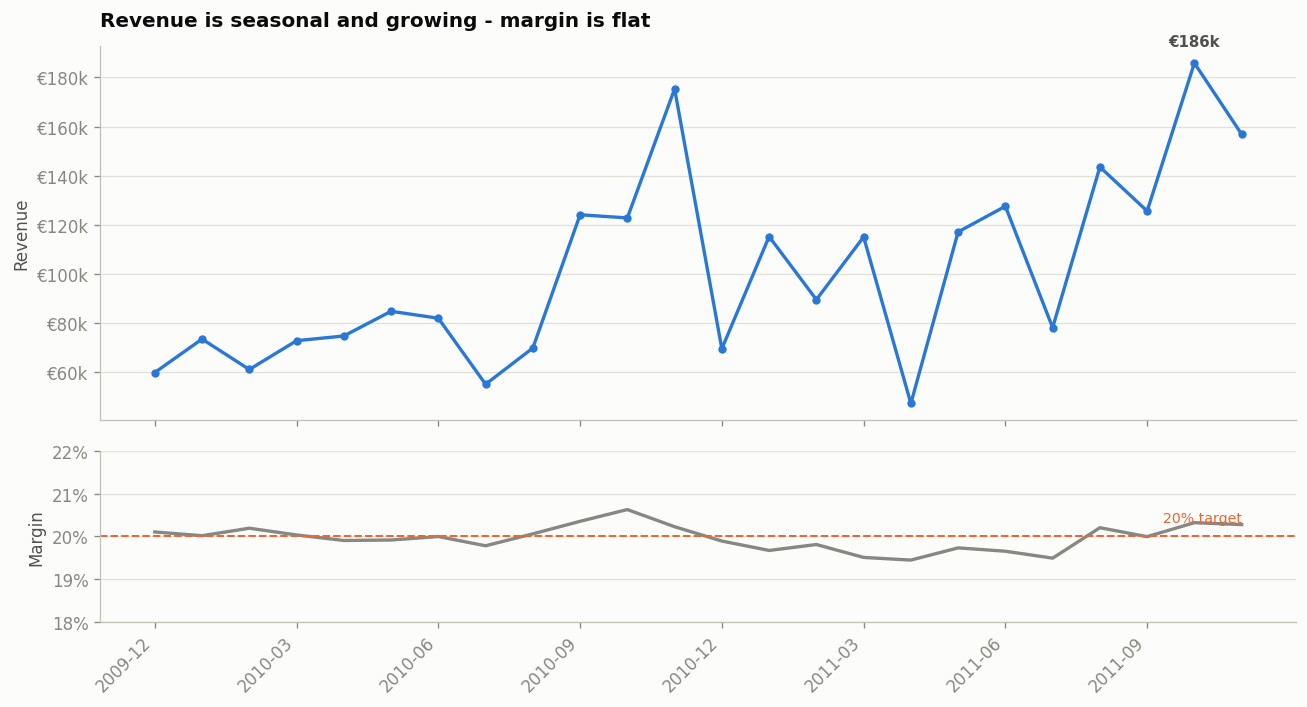

In [12]:
monthly = q('''
SELECT d.year_month,
       SUM(i.line_revenue) AS revenue,
       100.0 * SUM(i.line_profit) / SUM(i.line_revenue) AS margin_pct
FROM fact_order_items i
JOIN fact_orders o ON o.order_id = i.order_id
JOIN dim_date    d ON d.full_date = o.order_date
WHERE o.order_status = 'Completed'
GROUP BY d.year_month ORDER BY d.year_month
''')

# I drew this as one chart with two y-axes to begin with, because that is what Excel does
# by default. Then I looked at it and realised the point where the revenue line crosses
# the margin line looks meaningful and is completely meaningless - the two axes are euros
# and percent, so I could slide one scale up or down and move the crossing point
# anywhere. Two stacked panels sharing the x-axis says the same thing without the lie.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2.2, 1]})
x = range(len(monthly))
ax1.plot(x, monthly["revenue"], color=BLUE, lw=2, marker="o", ms=4)
ax1.set_title("Revenue is seasonal and growing - margin is flat", loc="left")
ax1.set_ylabel("Revenue"); ax1.yaxis.set_major_formatter(eur)
peak = monthly["revenue"].idxmax()
ax1.annotate(f"€{monthly['revenue'].max()/1000:,.0f}k",
             (peak, monthly["revenue"].max()), textcoords="offset points",
             xytext=(0, 10), ha="center", fontsize=9, color=INK_2, fontweight="bold")

ax2.plot(x, monthly["margin_pct"], color=MUTED, lw=2)
ax2.axhline(20, color=ORANGE, lw=1.2, ls="--")
ax2.text(len(monthly)-1, 20.35, "20% target", ha="right", fontsize=8.5, color=ORANGE)
ax2.set_ylabel("Margin"); ax2.set_ylim(18, 22)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax2.set_xticks(list(x)[::3]); ax2.set_xticklabels(monthly["year_month"][::3], rotation=45, ha="right")
plt.tight_layout(); plt.show()

Revenue has a clear November peak both years - this is a giftware retailer, so Christmas
stock-up is the whole business model. The margin panel is deliberately boring: it sits on
20% because **I calibrated it to**. It is a modelled number and that flat line is the
honest visual proof that it carries no information.

---

# Finding 2 - Where the revenue leaks

Two leaks worth measuring: orders that come back, and categories that sell well but earn
little.

In [13]:
leak = q('''
SELECT o.order_status,
       COUNT(DISTINCT o.order_id) AS orders,
       COUNT(*)                   AS lines,
       ROUND(SUM(i.line_revenue), 2) AS value
FROM fact_order_items i JOIN fact_orders o ON o.order_id = i.order_id
GROUP BY o.order_status ORDER BY value DESC
''')
total_demand = leak["value"].sum()
leak["% of gross demand"] = (leak["value"] / total_demand * 100).round(2)
leak

,order_status,orders,lines,value,% of gross demand
0,Completed,2640,60300,2428191.79,97.66
1,Returned,640,2016,58192.16,2.34


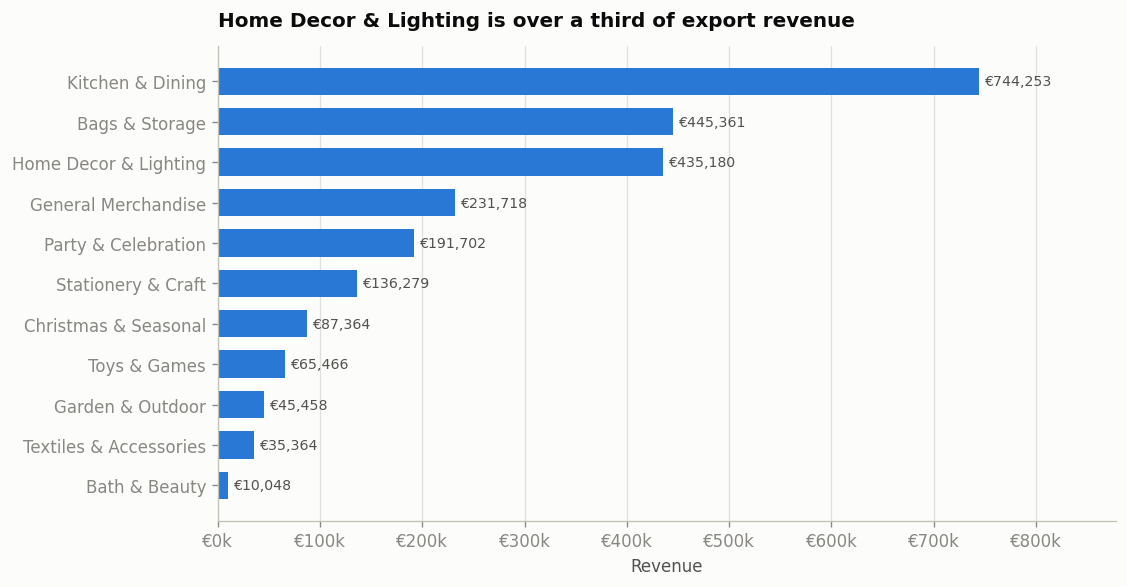

In [14]:
cat = q('''
SELECT c.category_name,
       SUM(i.line_revenue) AS revenue,
       100.0 * SUM(i.line_profit) / SUM(i.line_revenue) AS margin_pct
FROM fact_order_items i
JOIN fact_orders    o ON o.order_id    = i.order_id
JOIN dim_products   p ON p.product_id  = i.product_id
JOIN dim_categories c ON c.category_id = p.category_id
WHERE o.order_status = 'Completed'
GROUP BY c.category_name ORDER BY revenue DESC
''')

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.barh(cat["category_name"], cat["revenue"], color=BLUE, height=0.68)
ax.invert_yaxis(); ax.xaxis.set_major_formatter(eur); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
label_bars(ax, bars, fmt="€{:,.0f}", pad=6000)
ax.set_xlim(0, cat["revenue"].max() * 1.18)
ax.set_title("Home Decor & Lighting is over a third of export revenue", loc="left")
ax.set_xlabel("Revenue")
plt.tight_layout(); plt.show()

Returns cost **€58,192 - 2.3% of gross demand**, spread over 640 orders. That is a real
number a business could act on, and it is measured, not modelled.

I have deliberately *not* drawn a margin-by-category chart here. Margin is derived from my
own cost assumptions, so a chart ranking categories by margin would be a chart of my
assumptions dressed up as a finding. The revenue chart is real; the margin split is not.

---

# Finding 3 - Revenue is astonishingly concentrated

This is the finding that changed how I thought about the whole dataset.

In [15]:
pareto = q('''
WITH customer_revenue AS (
    SELECT o.customer_id, SUM(i.line_revenue) AS revenue
    FROM fact_order_items i JOIN fact_orders o ON o.order_id = i.order_id
    WHERE o.order_status = 'Completed'
    GROUP BY o.customer_id
),
ranked AS (
    SELECT revenue,
           NTILE(10) OVER (ORDER BY revenue DESC) AS decile
    FROM customer_revenue
)
SELECT decile, COUNT(*) AS customers, SUM(revenue) AS revenue
FROM ranked GROUP BY decile ORDER BY decile
''')
pareto["pct_of_revenue"]  = pareto["revenue"] / pareto["revenue"].sum() * 100
pareto["cumulative_pct"]  = pareto["pct_of_revenue"].cumsum()
pareto.style.format({"revenue": "€{:,.0f}", "pct_of_revenue": "{:.1f}%", "cumulative_pct": "{:.1f}%"})

,decile,customers,revenue,pct_of_revenue,cumulative_pct
0,1,51,"€1,601,757",66.0%,66.0%
1,2,51,"€292,524",12.0%,78.0%
2,3,51,"€189,428",7.8%,85.8%
3,4,51,"€116,602",4.8%,90.6%
4,5,51,"€77,472",3.2%,93.8%
5,6,51,"€55,513",2.3%,96.1%
6,7,51,"€40,165",1.7%,97.7%
7,8,51,"€28,132",1.2%,98.9%
8,9,50,"€18,154",0.7%,99.7%
9,10,50,"€8,446",0.3%,100.0%


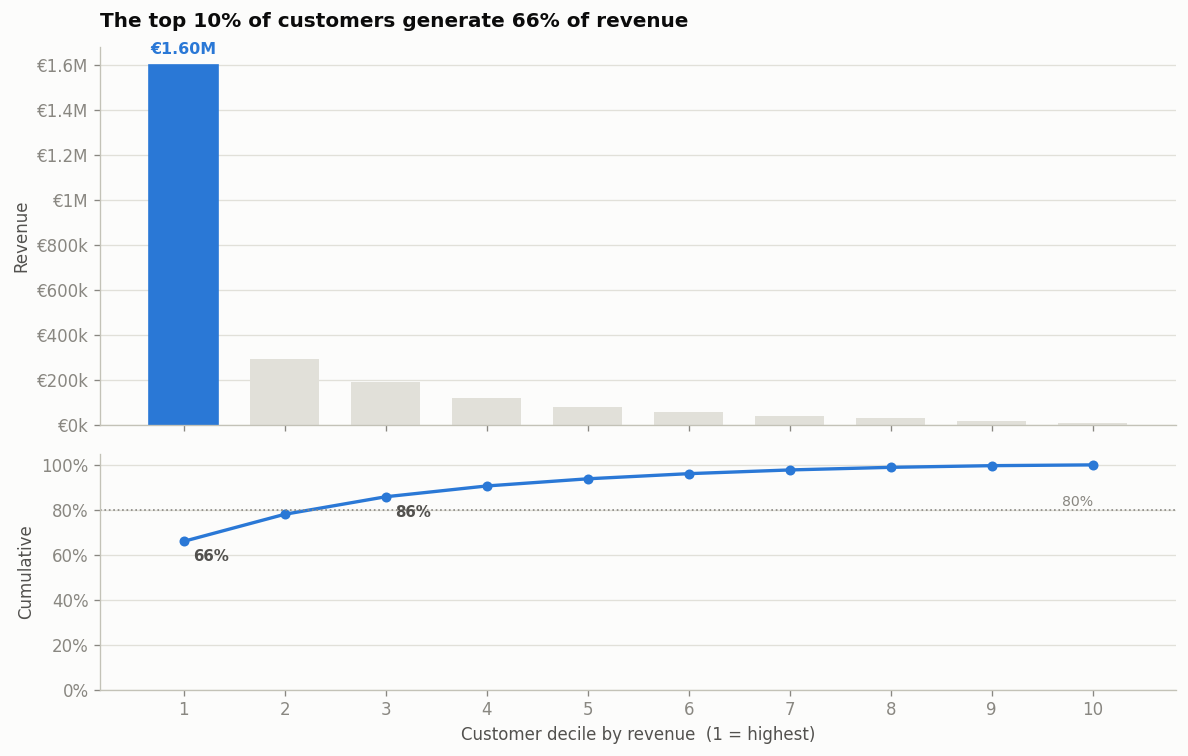

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [1.6, 1]})

bars = ax1.bar(pareto["decile"], pareto["revenue"], color=GRID, width=0.68)
# Everything grey except the first bar. Colouring all ten deciles differently would just
# be decoration - I only want the eye to go to the one that carries the business.
bars[0].set_color(BLUE)
ax1.yaxis.set_major_formatter(eur)
ax1.set_ylabel("Revenue")
ax1.set_title("The top 10% of customers generate 66% of revenue", loc="left")
ax1.text(1, pareto["revenue"].iloc[0]*1.03, f"€{pareto['revenue'].iloc[0]/1e6:.2f}M",
         ha="center", fontsize=9.5, fontweight="bold", color=BLUE)

ax2.plot(pareto["decile"], pareto["cumulative_pct"]/100, color=BLUE, lw=2, marker="o", ms=5)
ax2.axhline(0.8, color=MUTED, lw=1, ls=":")
ax2.text(10, 0.815, "80%", ha="right", fontsize=8.5, color=MUTED)
ax2.set_ylim(0, 1.05); ax2.yaxis.set_major_formatter(pct)
ax2.set_ylabel("Cumulative"); ax2.set_xlabel("Customer decile by revenue  (1 = highest)")
ax2.set_xticks(range(1, 11))
for d in (1, 3):
    ax2.annotate(f"{pareto['cumulative_pct'].iloc[d-1]:.0f}%", (d, pareto["cumulative_pct"].iloc[d-1]/100),
                 textcoords="offset points", xytext=(6, -12), fontsize=9, color=INK_2, fontweight="bold")
plt.tight_layout(); plt.show()

**The top decile alone is €1.60M of the €2.43M.** By the third decile you are already at
86% of revenue, and the bottom half of the customer base is worth about 6% put together.

My resume bullet originally said "the top 30% drive 60% of revenue" - which is what I
*expected* from the usual Pareto rule of thumb. The real data says the top 30% drive
**86%**, and the top **10%** drive 66%. The real concentration is far more extreme than
the textbook 80/20, which for a business means retention effort should be aimed at a
list of about 50 accounts rather than a mass email campaign.

---

# Finding 4 - Retention collapses in month 1, then holds

Cohort analysis: group every customer by the month of their first purchase, then follow
that same group forward and count how many come back.

Doing it this way rather than looking at total monthly customers matters, because the
customer count kept growing while retention was quietly getting worse - the new customers
were hiding the drop-off.

In [17]:
cohort = q('''
WITH orders AS (
    SELECT o.customer_id, d.year_month AS order_month,
           d.year * 12 + d.month_number AS month_num
    FROM fact_orders o JOIN dim_date d ON d.full_date = o.order_date
    WHERE o.order_status = 'Completed'
),
first_order AS (
    SELECT customer_id, MIN(order_month) AS cohort_month, MIN(month_num) AS cohort_num
    FROM orders GROUP BY customer_id
),
activity AS (
    SELECT f.cohort_month, o.customer_id, o.month_num - f.cohort_num AS month_index
    FROM orders o JOIN first_order f ON f.customer_id = o.customer_id
),
size AS (
    SELECT cohort_month, COUNT(DISTINCT customer_id) AS cohort_customers
    FROM first_order GROUP BY cohort_month
)
SELECT a.cohort_month, s.cohort_customers, a.month_index,
       COUNT(DISTINCT a.customer_id) AS active,
       100.0 * COUNT(DISTINCT a.customer_id) / s.cohort_customers AS retention_pct
FROM activity a JOIN size s ON s.cohort_month = a.cohort_month
GROUP BY a.cohort_month, s.cohort_customers, a.month_index
ORDER BY a.cohort_month, a.month_index
''')

matrix = cohort.pivot(index="cohort_month", columns="month_index", values="retention_pct")

# I leave month 0 out of this table. It is 100% for every single cohort by definition
# (that is the month they joined), so it carries no information and it breaks the colour
# scale - with a 100 in the data everything else shades to the same pale blue.
matrix.iloc[:8, 1:11].style.format("{:.0f}%", na_rep="") \
      .background_gradient(cmap="Blues", vmin=0, vmax=40)

month_index,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,
2009-12,34%,40%,47%,40%,38%,47%,30%,32%,51%,47%
2010-01,22%,30%,26%,37%,19%,41%,19%,41%,37%,30%
2010-02,23%,26%,16%,29%,13%,29%,29%,23%,29%,10%
2010-03,10%,13%,17%,20%,10%,17%,27%,20%,10%,13%
2010-04,15%,4%,8%,12%,23%,27%,31%,15%,27%,8%
2010-05,19%,14%,14%,14%,29%,10%,10%,5%,29%,14%
2010-06,21%,12%,17%,25%,25%,8%,21%,8%,12%,12%
2010-07,18%,27%,27%,36%,18%,27%,27%,32%,9%,32%


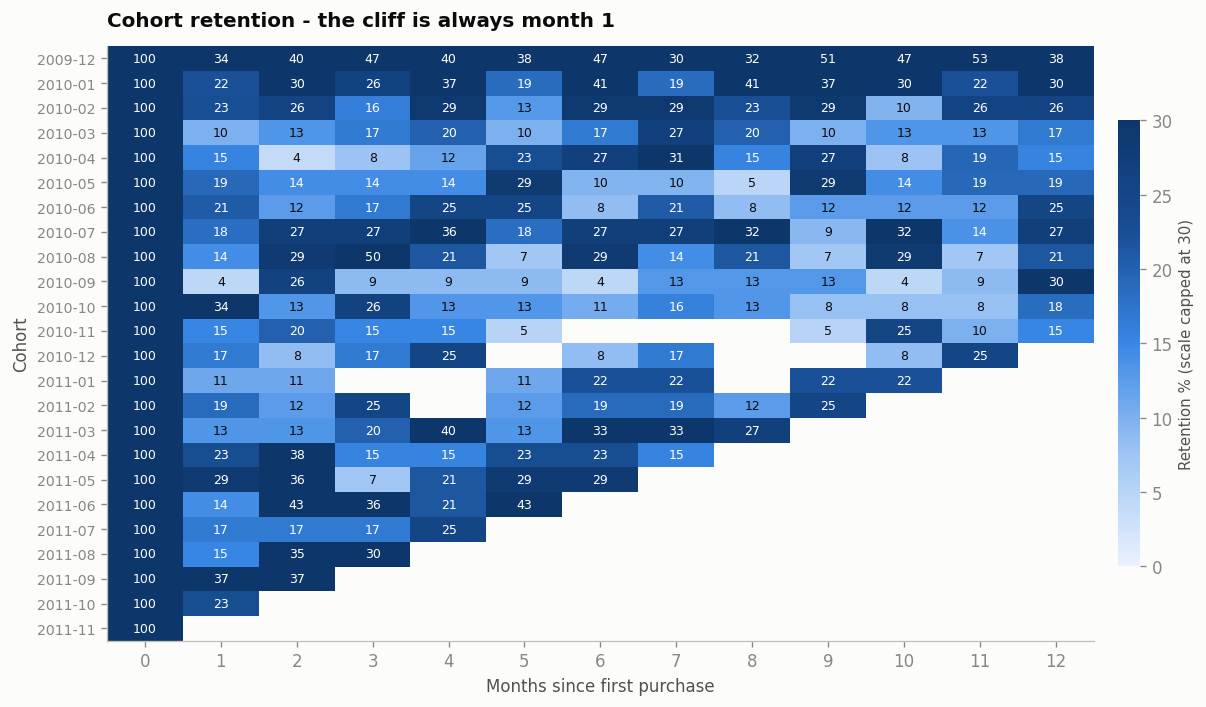

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
m = matrix.iloc[:, :13]
# The cap at 30 is the whole trick with this chart. My first version used the default
# scale, and because month 0 is always 100 it grabbed the entire dark end of the colour
# ramp - every other cell came out nearly white and the map looked empty. Capping the
# scale at 30 means the colours spread across the range the real numbers actually live
# in, and month 0 just saturates. I say so on the colour bar so nobody misreads it.
im = ax.imshow(m.values, cmap=BLUES, vmin=0, vmax=30, aspect="auto")
ax.set_xticks(range(m.shape[1])); ax.set_xticklabels(m.columns)
ax.set_yticks(range(m.shape[0])); ax.set_yticklabels(m.index, fontsize=8.5)
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Cohort")
ax.set_title("Cohort retention - the cliff is always month 1", loc="left")
ax.grid(False)
norm = plt.Normalize(vmin=0, vmax=30)
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="white" if on_dark(BLUES(norm(v))) else INK)
cb = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cb.set_label("Retention % (scale capped at 30)", fontsize=9); cb.outline.set_visible(False)
plt.tight_layout(); plt.show()

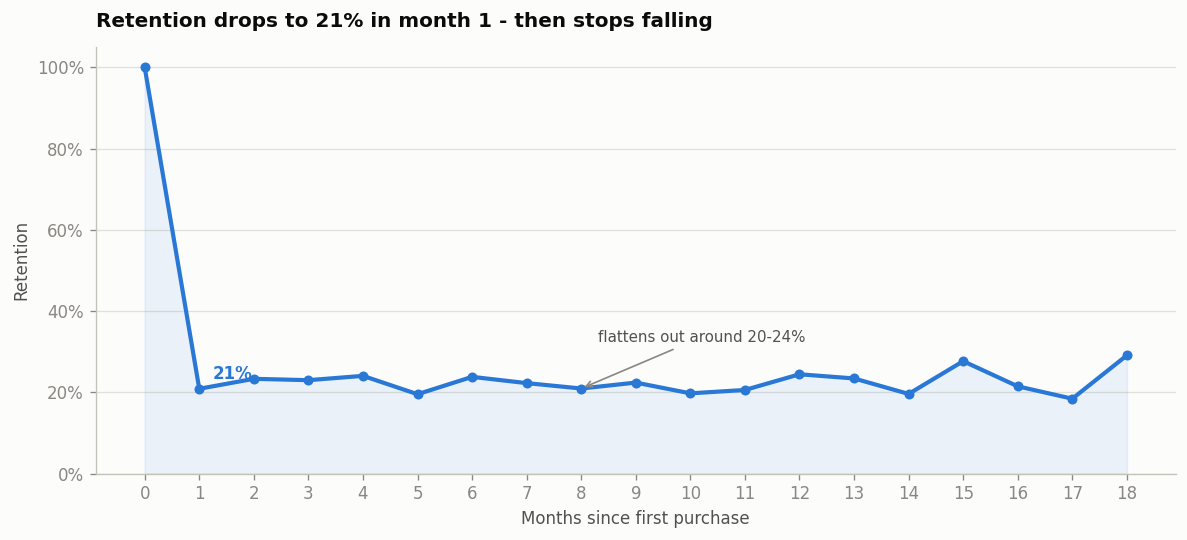

In [19]:
curve = (cohort.groupby("month_index")
               .apply(lambda g: 100.0 * g["active"].sum() / g["cohort_customers"].sum())
               .reset_index(name="retention_pct"))
curve = curve[curve["month_index"] <= 18]

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(curve["month_index"], curve["retention_pct"], color=BLUE, lw=2.5, marker="o", ms=5)
ax.fill_between(curve["month_index"], curve["retention_pct"], color=BLUE, alpha=0.08)
ax.set_xticks(curve["month_index"])
ax.set_ylim(0, 105); ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Retention")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Retention drops to 21% in month 1 - then stops falling", loc="left")
ax.annotate(f"{curve['retention_pct'].iloc[1]:.0f}%", (1, curve["retention_pct"].iloc[1]),
            textcoords="offset points", xytext=(8, 6), fontsize=10, fontweight="bold", color=BLUE)
ax.annotate("flattens out around 20-24%", (8, curve["retention_pct"].iloc[8]),
            textcoords="offset points", xytext=(10, 28), fontsize=9, color=INK_2,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
plt.tight_layout(); plt.show()

This is the shape I did not expect. Retention falls off a cliff immediately - **79% of
customers do not come back the next month** - but then it *stops falling* and settles
around 20-24% for the next year and a half.

That changes the recommendation completely. If retention decayed steadily you would spend
continuously on win-back. It does not: whoever survives month 1 tends to stick around. So
**the first 30 days is the only window that matters**, and that is where onboarding and
follow-up spend should go.

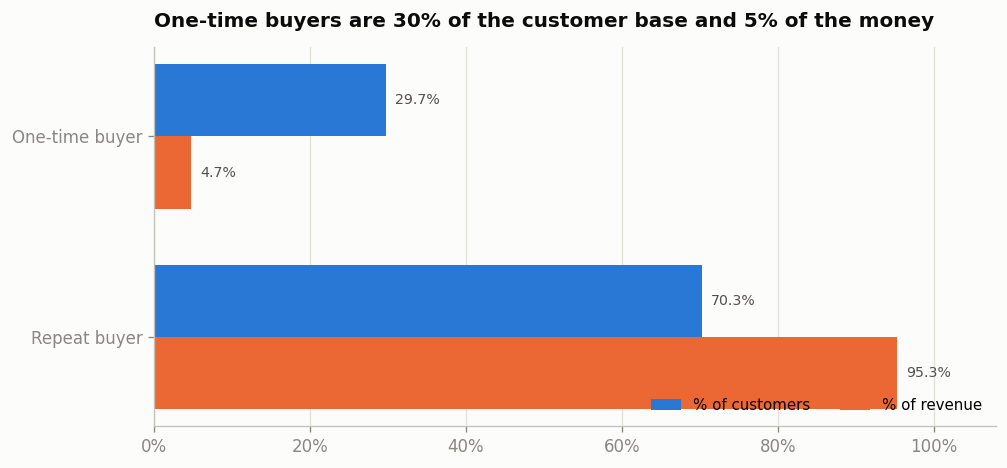

In [20]:
freq = q('''
WITH per_customer AS (
    SELECT o.customer_id, COUNT(DISTINCT o.order_id) AS orders, SUM(i.line_revenue) AS revenue
    FROM fact_orders o JOIN fact_order_items i ON i.order_id = o.order_id
    WHERE o.order_status = 'Completed' GROUP BY o.customer_id
)
SELECT CASE WHEN orders = 1 THEN 'One-time buyer' ELSE 'Repeat buyer' END AS customer_type,
       COUNT(*) AS customers, SUM(revenue) AS revenue
FROM per_customer GROUP BY 1
''')
freq["% of customers"] = freq["customers"] / freq["customers"].sum() * 100
freq["% of revenue"]   = freq["revenue"]   / freq["revenue"].sum()   * 100

fig, ax = plt.subplots(figsize=(8.5, 4))
y = np.arange(len(freq)); h = 0.36
b1 = ax.barh(y - h/2, freq["% of customers"], h, color=BLUE,   label="% of customers")
b2 = ax.barh(y + h/2, freq["% of revenue"],   h, color=ORANGE, label="% of revenue")
ax.set_yticks(y); ax.set_yticklabels(freq["customer_type"]); ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.grid(axis="x"); ax.grid(axis="y", visible=False); ax.set_xlim(0, 108)
for bars in (b1, b2):
    label_bars(ax, bars, fmt="{:.1f}%", pad=1.2)
ax.legend(loc="lower right", ncol=2, fontsize=9)
ax.set_title("One-time buyers are 30% of the customer base and 5% of the money", loc="left")
plt.tight_layout(); plt.show()

---

# Finding 5 - Turning it into something marketing can use

A finding nobody can act on is not worth much. RFM segmentation scores every customer on
**R**ecency, **F**requency and **M**onetary value (1-5 each, 5 always good), then buckets
them into named segments.

Note `reference_date` - "today" is the last order date in the dataset, not the actual
current date. Using `CURRENT_DATE` would make all 508 customers look churned, because the
data stops in 2011.

In [21]:
rfm = q('''
WITH ref AS (SELECT MAX(order_date) AS max_date FROM fact_orders WHERE order_status='Completed'),
base AS (
    SELECT o.customer_id,
           JULIANDAY((SELECT max_date FROM ref)) - JULIANDAY(MAX(o.order_date)) AS recency_days,
           COUNT(DISTINCT o.order_id) AS frequency,
           SUM(i.line_revenue)        AS monetary
    FROM fact_orders o JOIN fact_order_items i ON i.order_id = o.order_id
    WHERE o.order_status = 'Completed' GROUP BY o.customer_id
),
scored AS (
    SELECT *,
        6 - NTILE(5) OVER (ORDER BY recency_days ASC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC)        AS f_score,
        NTILE(5) OVER (ORDER BY monetary  ASC)        AS m_score
    FROM base
)
SELECT *,
    CASE WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
         WHEN r_score >= 3 AND f_score >= 3                  THEN 'Loyal Customers'
         WHEN r_score >= 4 AND f_score <= 2                  THEN 'New Customers'
         WHEN r_score  = 3 AND f_score <= 2                  THEN 'Promising'
         WHEN r_score <= 2 AND f_score >= 4 AND m_score >= 4 THEN 'At Risk - High Value'
         WHEN r_score <= 2 AND f_score >= 3                  THEN 'At Risk'
         WHEN r_score <= 2 AND f_score <= 2 AND m_score >= 3 THEN 'Hibernating'
         ELSE 'Lost' END AS segment
FROM scored
''')

seg = (rfm.groupby("segment")
          .agg(customers=("customer_id", "size"), revenue=("monetary", "sum"),
               avg_orders=("frequency", "mean"), avg_recency=("recency_days", "mean"))
          .sort_values("revenue", ascending=False).reset_index())
seg["% of revenue"] = seg["revenue"] / seg["revenue"].sum() * 100
seg.style.format({"revenue": "€{:,.0f}", "avg_orders": "{:.1f}", "avg_recency": "{:.0f}d",
                  "% of revenue": "{:.1f}%"})

,segment,customers,revenue,avg_orders,avg_recency,% of revenue
0,Champions,108,"€1,762,106",14.3,17d,72.6%
1,Loyal Customers,117,"€316,257",4.4,53d,13.0%
2,At Risk - High Value,21,"€115,561",6.6,270d,4.8%
3,At Risk,58,"€88,794",3.1,329d,3.7%
4,Hibernating,23,"€45,770",1.0,405d,1.9%
5,Lost,100,"€39,903",1.3,417d,1.6%
6,Promising,38,"€36,442",1.3,87d,1.5%
7,New Customers,43,"€23,359",1.4,24d,1.0%


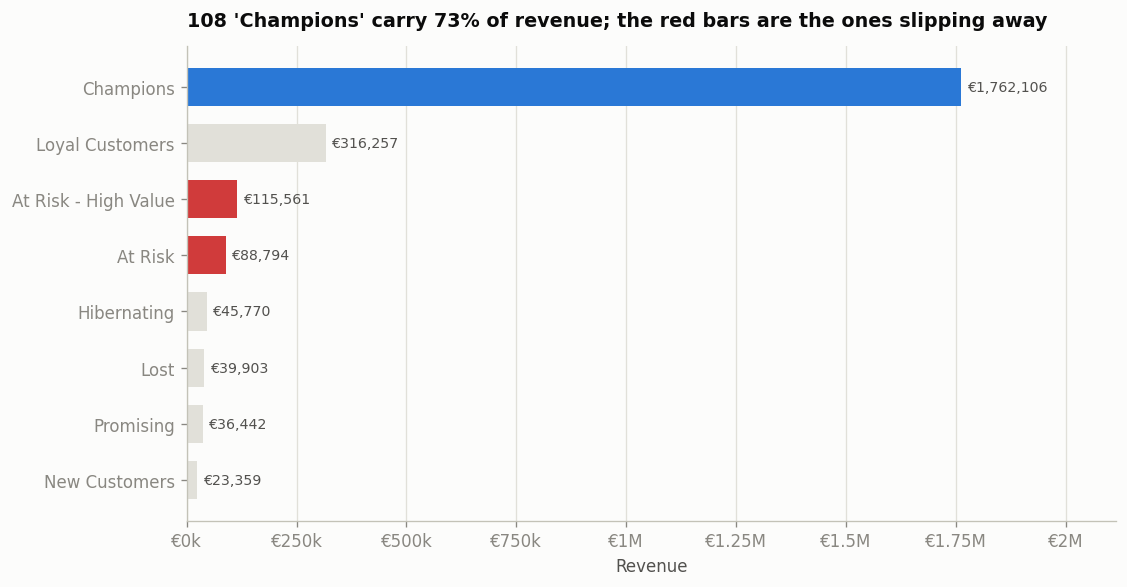

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 5))
colors = [BLUE if s == "Champions" else (RED if "At Risk" in s else GRID) for s in seg["segment"]]
bars = ax.barh(seg["segment"], seg["revenue"], color=colors, height=0.68)
ax.invert_yaxis(); ax.xaxis.set_major_formatter(eur)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
label_bars(ax, bars, fmt="€{:,.0f}", pad=15000)
ax.set_xlim(0, seg["revenue"].max() * 1.2)
ax.set_title("108 'Champions' carry 73% of revenue; the red bars are the ones slipping away",
             loc="left", fontsize=11.5)
ax.set_xlabel("Revenue")
plt.tight_layout(); plt.show()

In [23]:
# This is the bit I would actually hand over. Three conditions: they have ordered at
# least 3 times so I know they are not a one-off, they are worth at least EUR 3,000 so
# chasing them is worth the effort, and they have been silent for 6 months or more.
# I set the value bar at 3,000 because the average customer here is worth about 4,800 -
# my first go used 300 and returned a list of people who had barely bought anything.
winback = (rfm[(rfm["frequency"] >= 3) & (rfm["monetary"] >= 3000) & (rfm["recency_days"] >= 180)]
             .sort_values("monetary", ascending=False)
             [["customer_id", "frequency", "monetary", "recency_days", "segment"]])
print(f"{len(winback)} customers worth €{winback['monetary'].sum():,.0f} have not ordered in 6+ months\n")
winback.head(10).style.format({"monetary": "€{:,.0f}", "recency_days": "{:.0f}d"})

13 customers worth €89,434 have not ordered in 6+ months



,customer_id,frequency,monetary,recency_days,segment
480,12482,27,"€25,200",567d,At Risk - High Value
384,14439,5,"€10,859",310d,At Risk - High Value
331,14442,7,"€6,170",195d,At Risk - High Value
361,12755,11,"€6,019",271d,At Risk - High Value
403,15332,6,"€5,628",357d,At Risk - High Value
371,17829,5,"€5,474",289d,At Risk - High Value
335,12625,4,"€5,380",202d,At Risk - High Value
360,17508,8,"€5,266",271d,At Risk - High Value
495,13902,4,"€5,109",623d,At Risk - High Value
358,12623,7,"€3,814",267d,At Risk - High Value


That last table is the point of the whole project. It is a list a marketing team can load
into an email tool tomorrow morning - a small number of named accounts, each worth real
money, each of which has gone quiet.

---

# What I would do differently

- **The cost model is the weak point.** Everything else here is measured; margin is
  assumed. If I did this again I would pick a dataset with real costs even if the revenue
  numbers were less impressive, because "modelled margin" is a caveat I have to explain
  every single time.
- **508 customers is thin for cohort work.** The median cohort is about 20 people, so
  individual cells in that heat map bounce around a lot. The UK segment has 5,334
  customers and much smoother cohorts - the trade was scope realism against sample size,
  and next time I would run both side by side.
- **My Pareto assumption was wrong and I should have checked first.** I went in expecting
  80/20 and wrote it into my project plan before looking. The data said something more
  extreme, and it took me a while to believe the query rather than my expectation.
- **Everything reloads from scratch.** Fine at 62k rows, useless at 62 million. A real
  version needs incremental loading.

# Summary

| Metric | Value | Measured or modelled? |
|---|---|---|
| Transactions | 62,316 | measured |
| Revenue | €2,428,192 | measured |
| Orders / customers | 2,640 / 508 | measured |
| Average order value | €919.77 | measured |
| Top 10% of customers | 65.7% of revenue | measured |
| Top 30% of customers | 85.7% of revenue | measured |
| One-time buyers | 29.7% of customers, 4.7% of revenue | measured |
| Month-1 retention | 20.9%, flattening to 20-24% | measured |
| Revenue lost to returns | €58,192 (2.3%) | measured |
| **Profit margin** | **20.0%** | **modelled - cost column does not exist** |

The SQL that produced all of this lives in `sql/`, the cleaning pipeline in
`python/clean_online_retail.py`, and the Power BI model in `powerbi/`.